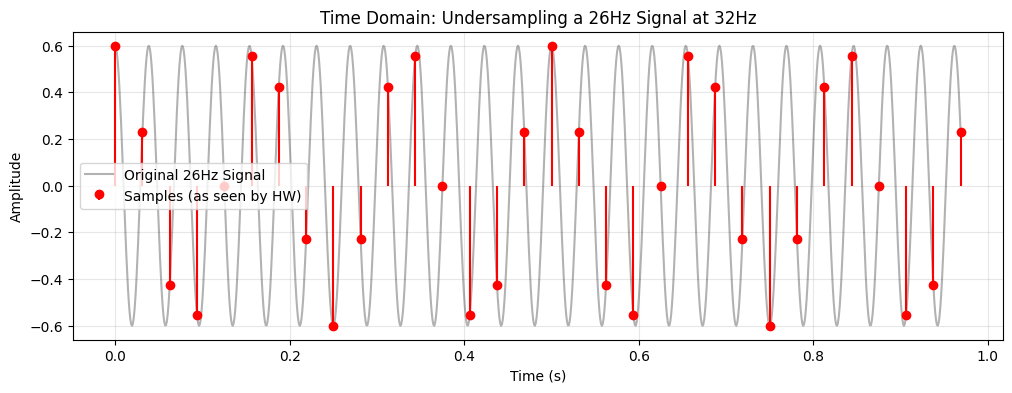

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from fft_utils import run_sim

# Parameters
N = 32          # HW FFT size
fs = 32         # Sampling frequency (Hz)
f_sig = 26      # Signal frequency (Hz) -> VIOLATES NYQUIST (fs/2 = 16Hz)

# 1. Generate "Continuous" signal (for display) and "Sampled" signal (for HW)
t_cont = np.linspace(0, (N-1)/fs, 1000)
sig_cont = 0.6 * np.cos(2 * np.pi * f_sig * t_cont)

t_sampled = np.arange(N) / fs
sig_sampled = 0.6 * np.cos(2 * np.pi * f_sig * t_sampled)

# Plotting
plt.figure(figsize=(12, 4))
plt.plot(t_cont, sig_cont, 'k-', alpha=0.3, label=f"Original {f_sig}Hz Signal")
plt.stem(t_sampled, sig_sampled, linefmt='r-', markerfmt='ro', basefmt=' ', label="Samples (as seen by HW)")
plt.title("Time Domain: Undersampling a 26Hz Signal at 32Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

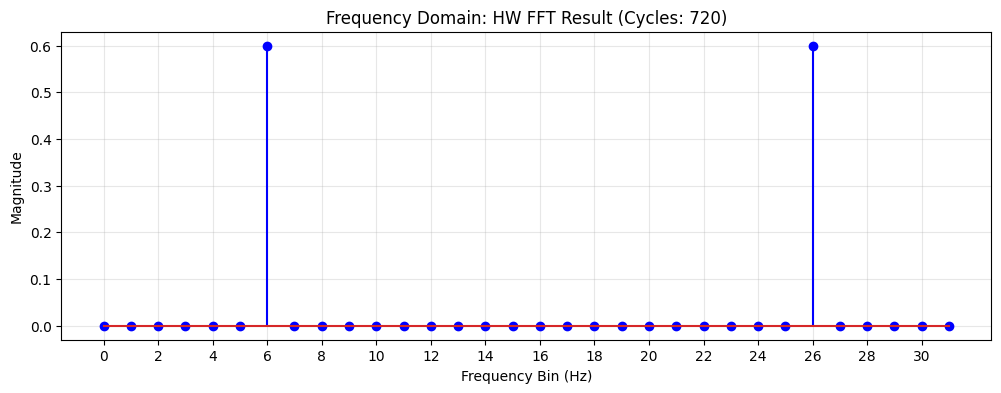

In [9]:
# 2. Run Hardware FFT
# We pass the sampled array directly to our new run_sim function
fft_hw, exp1, cycles = run_sim(sig_sampled, invert=False)

# Plotting the Spectrum
plt.figure(figsize=(12, 4))
freqs = np.arange(N)
plt.stem(freqs, np.abs(fft_hw), linefmt='b-', markerfmt='bo')

plt.title(f"Frequency Domain: HW FFT Result (Cycles: {cycles})")
plt.xlabel("Frequency Bin (Hz)")
plt.ylabel("Magnitude")
plt.xticks(np.arange(0, N, 2))
plt.grid(True, alpha=0.3)
plt.show()

#print(f"Notice: The peak is at Bin 6, because |{f_sig} - {fs}| = 6.")

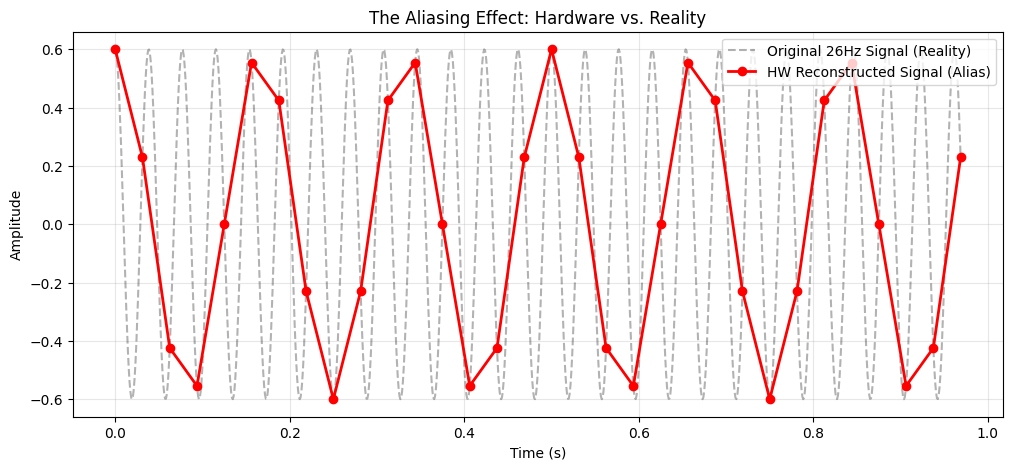

The red line is a 6Hz signal. The hardware is mathematically correct,
but because we undersampled, the 26Hz signal is lost forever!


In [14]:
# 3. Run Hardware IFFT
# We pass the FFT result back into the hardware to reconstruct the time domain
# Note: Since our run_sim handles quantization, we pass the complex fft_hw
sig_reconstructed, exp2, cycles_i = run_sim(fft_hw, invert=True)

# Note the scaling methodology to restore the absolute amplitude of the original
sig_reconstructed = sig_reconstructed * (2**(exp2+exp1)) / N

# Plotting comparison
plt.figure(figsize=(12, 5))
plt.plot(t_cont, sig_cont, 'k--', alpha=0.3, label=f"Original {f_sig}Hz Signal (Reality)")
plt.plot(t_sampled, np.real(sig_reconstructed), 'r-o', linewidth=2, label="HW Reconstructed Signal (Alias)")

plt.title("The Aliasing Effect: Hardware vs. Reality")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

print(f"The red line is a 6Hz signal. The hardware is mathematically correct,")
print(f"but because we undersampled, the 26Hz signal is lost forever!")

Running Forward HW FFT (N=128)...
Running Inverse HW FFT (N=128)...


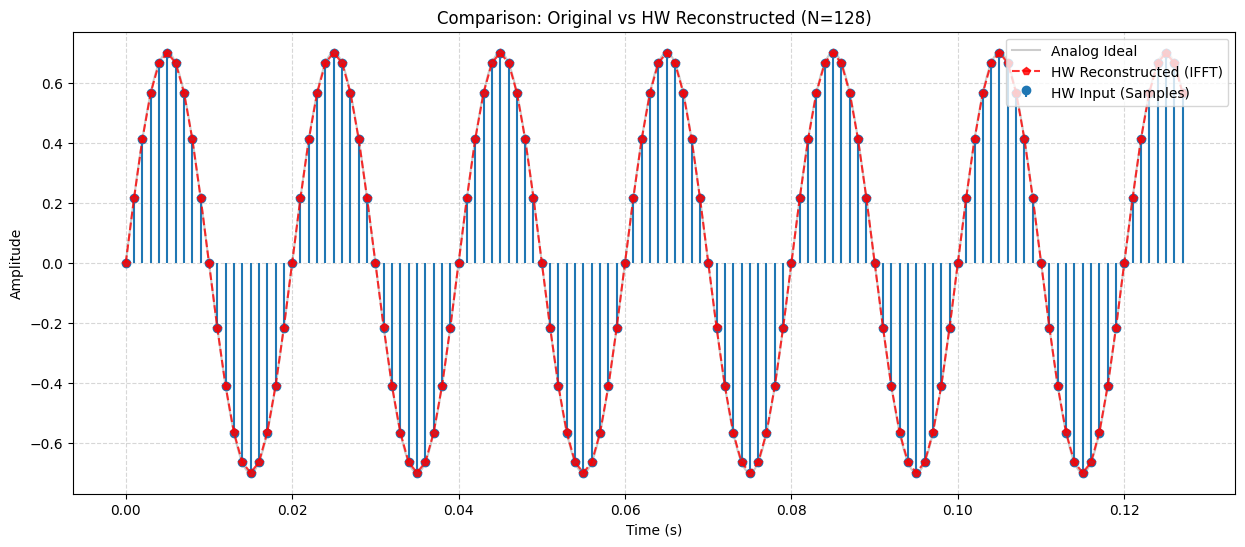

Mean Squared Error: 6.18e-02


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from fft_utils import run_sim 

# 1. Increase N for a smoother look
N = 128          # Hardware will re-compile for 128 points
fs = 1000        # 1kHz Sampling rate
f_sig = 50       # 50Hz Signal (fits 6.4 times in this window)

# Create a smooth time vector for the "Ideal" wave
t_fine = np.linspace(0, (N-1)/fs, 1000)
sig_ideal = 0.7 * np.sin(2 * np.pi * f_sig * t_fine)

# Create the sampled vector for the HW
t_sampled = np.arange(N) / fs
input_sig = 0.7 * np.sin(2 * np.pi * f_sig * t_sampled).astype(complex)

# Leacage to the first sample can be fixed by centering the wave
#f_centered = (6 * 1000) / 128
#input_sig = 0.7 * np.sin(2 * np.pi * f_centered * t_sampled).astype(complex)

# --- Step 1: Forward FFT ---
print(f"Running Forward HW FFT (N={N})...")
fft_hw, e, _ = run_sim(input_sig, invert=False)

# --- Step 2: Inverse FFT ---
print(f"Running Inverse HW FFT (N={N})...")
reconstructed_sig, e2, _ = run_sim(fft_hw, invert=True)

# 2. Plotting for comparison
plt.figure(figsize=(15, 6))

# Plot the "Continuous" ideal wave for reference
plt.plot(t_fine, sig_ideal, 'k-', alpha=0.2, label='Analog Ideal')

# Plot the points the Hardware actually processed
plt.stem(t_sampled, input_sig.real, linefmt='C0-', markerfmt='C0o', 
         label='HW Input (Samples)', basefmt=" ")

# Plot what came back out of the IFFT
plt.plot(t_sampled, reconstructed_sig.real*(2**(e+e2)/N), 'r--p', alpha=0.8, 
         label='HW Reconstructed (IFFT)')

plt.title(f"Comparison: Original vs HW Reconstructed (N={N})")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# 3. Check for the "Missing" Signal
mse = np.mean(np.abs(input_sig - reconstructed_sig)**2)
print(f"Mean Squared Error: {mse:.2e}")

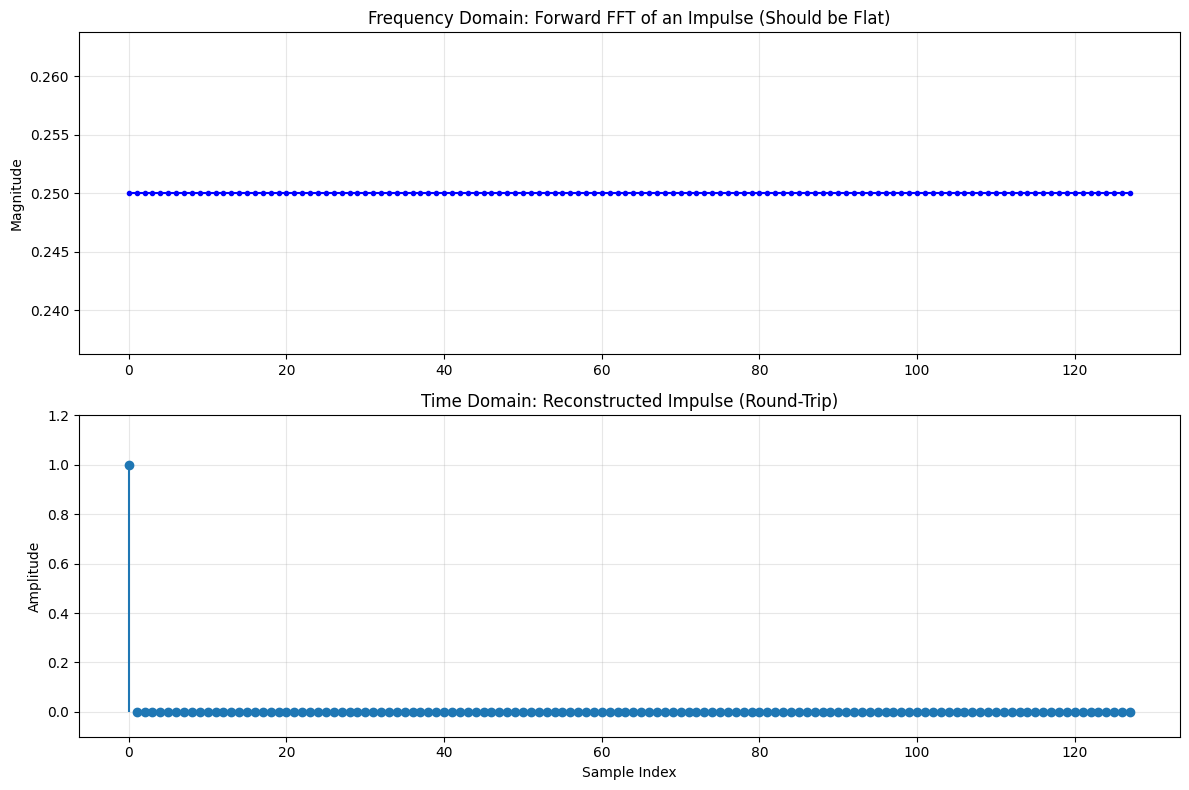

Sample 0 Amplitude: 1.0000
Sample 1 Amplitude: 0.0000


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from fft_utils import run_sim

# 1. Create the Impulse at Index 0
N = 128
input_sig = np.zeros(N, dtype=complex)
input_sig[0] = 1.0  # The "Impulse"

# --- Step 1: Forward FFT ---
# Expected: A flat magnitude across all bins
fft_hw, e1, _ = run_sim(input_sig, invert=False)

# --- Step 2: Inverse FFT ---
# Expected: The original [1, 0, 0, ...] impulse
reconstructed_sig, e2, _ = run_sim(fft_hw, invert=True)

# 2. Apply your Scaling Equation
# Multiply by 2**(e1+e2) and divide by N as per your manual correction
final_sig = (reconstructed_sig.real * (2.0**(e1 + e2))) / N

# 3. Plotting the results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Frequency Domain Plot
ax1.plot(np.abs(fft_hw), 'b-o', markersize=3)
ax1.set_title("Frequency Domain: Forward FFT of an Impulse (Should be Flat)")
ax1.set_ylabel("Magnitude")
ax1.grid(True, alpha=0.3)

# Time Domain Plot
ax2.stem(np.arange(N), final_sig, basefmt=" ")
ax2.set_title("Time Domain: Reconstructed Impulse (Round-Trip)")
ax2.set_xlabel("Sample Index")
ax2.set_ylabel("Amplitude")
ax2.set_ylim([-0.1, 1.2])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Sample 0 Amplitude: {final_sig[0]:.4f}")
print(f"Sample 1 Amplitude: {final_sig[1]:.4f}")